# Set up

In [24]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod

In [26]:
from utils import *

## Constants

In [27]:
SEED = 42
LEARNING_RATE = 0.01
MAX_ITER = 10000

# Process data

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. ĐỌC DỮ LIỆU TỪ FILE CSV ĐÃ LƯU
try:
    df = pd.read_csv('data/dataset.csv')
    print("Đã tải dữ liệu thành công.")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'dataset.csv'. Hãy chạy file xử lý trước đó.")
    exit()

# 2. TÁCH BIẾN ĐẶC TRƯNG (X) VÀ BIẾN MỤC TIÊU (y)
# Loại bỏ cột 'Class' (chuỗi) và 'Class_Encoded' (mục tiêu) ra khỏi X
X = df.drop(['Class', 'Class_Encoded'], axis=1)
y = df['Class_Encoded']

# 3. CHIA DỮ LIỆU: TRAIN (70%) / VAL (10%) / TEST (20%)
# Bước 1: Tách 20% cho Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Bước 2: Tách 10% (trên tổng số) cho Validation từ phần 80% còn lại
# Tỷ lệ test_size = 0.125 vì 0.125 * 0.8 = 0.1 (tức 10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

# 4. CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)
# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# LƯU Ý: Chỉ "fit" trên tập Train để tránh rò rỉ dữ liệu (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# "transform" cho tập Val và Test dựa trên thông số của tập Train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. KIỂM TRA KẾT QUẢ
print("-" * 30)
print(f"Tổng số mẫu: {len(df)}")
print(f"Tập Huấn luyện (Train):    {X_train_scaled.shape}")
print(f"Tập Kiểm chứng (Val):     {X_val_scaled.shape}")
print(f"Tập Kiểm tra (Test):      {X_test_scaled.shape}")
print("-" * 30)

Đã tải dữ liệu thành công.
------------------------------
Tổng số mẫu: 13611
Tập Huấn luyện (Train):    (9527, 9)
Tập Kiểm chứng (Val):     (1361, 9)
Tập Kiểm tra (Test):      (2723, 9)
------------------------------


# Model

# Logistic Regression

hypothesis: $h_{\theta}(x) = g(\theta^T x)$

sigmoid function: $g(z) = \frac{1}{1 + e^{-z}}$

$0 \ge h_{\theta}(x) \le 1$ 

$h_{\theta}(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$ can be interpreted as the posterior probability. For classification
use step function:  
$h_{\theta}(x) \le 0.5 \rightarrow 0$   
$h_{\theta}(x) > 0.5 \rightarrow 1$ 

$h_{\theta}(x):  \theta_1 x_1 + \dots + \theta_n x_n >  \theta_0$

equivalent to 

$h_{\theta}(x) = -\theta_0 + \theta_1 x_1 + \dots + \theta_n x_n > 0$

Linear Regression Cost function (gradiend descent):
    
$J(\theta) = \frac{1}{2m} \sum (h_{\theta}(x^{(i)}) - y)^2$

Now using  $\frac{1}{1 + e^{-\theta^T x}}$ (not convex anymore)

### Cost Function and Gradient

$J(\theta) = \frac{1}{m} \sum^{m}_{i=1} \big[ -y^{(i)} log(h_{\theta}(x^{(i)})) - (1-y^{(i)})log(1-h_{\theta}(x^{(i)}))  \big]$

$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j$

### Update Rule

$\theta_j := \theta_j - \alpha \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j$

## Regularization

$$J(\theta) = \frac{1}{m} \sum^{m}_{i=1} \big[ -y^{(i)} \
log(h_{\theta}(x^{(i)})) - \
(1-y^{(i)})log(1-h_{\theta}(x^{(i)}))  \big]\
%regularize\
+ \frac{\lambda}{2m} \sum_{j=1}^{n} \theta^2_j$$

Do not regularize $\theta_0$

$$\frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j \
\quad \quad \text{for } j = 0$$

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j \
+ \frac{\lambda}{m} \theta_j \
\quad \quad \text{for } j \ge 1$$

## Base

In [29]:
class Classification(ABC):
  @abstractmethod
  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    """
    Fit the model to the training data.
    """
    pass

  @abstractmethod
  def predict(self, X: np.ndarray) -> np.ndarray:
    """
    Predict the target values for the given input data.
    """
    pass

  @abstractmethod
  def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Evaluate the model on the given input and target data.
    """
    pass

## Logistic Regression

In [30]:
class LogisticRegression(Classification):
  def __init__(
    self,
    random_state: int = SEED ,
    solver: str = 'gradient_descent',
    learning_rate: float = LEARNING_RATE,
    max_iter: int = MAX_ITER,
  ):
    self.random_state = random_state
    self.solver = solver
    self.learning_rate = learning_rate
    self.max_iter = max_iter
    self.coef_ = None
    self.intercept_ = None
    
  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    raise NotImplementedError('Not implemented yet')

  def predict(self, X: np.ndarray) -> np.ndarray:
    raise NotImplementedError('Not implemented yet')

  def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
    raise NotImplementedError('Not implemented yet')

# Logistic Regression (nhị phân và đa lớp):


Cài đặt Gradient Descent từ đầu cho nhị phân (sigmoid) và đa lớp (softmax).

In [31]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x)) # Subtracting max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [32]:
import numpy as np

class LogisticRegression:
    def __init__(
        self,
        random_state: int = 42,
        solver: str = 'gradient_descent',
        learning_rate: float = 0.01,
        max_iter: int = 1000,
    ):
        self.random_state = random_state
        self.solver = solver
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        Maps values to [0, 1] using the logistic function:
        1 / (1 + exp(-z))
        """
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        # Set random seed for reproducibility
        if self.random_state:
            np.random.seed(self.random_state)
            
        n_samples, n_features = X.shape
        
        # Initialize weights (coef_) and bias (intercept_) to zeros
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        # Gradient Descent Loop
        for _ in range(self.max_iter):
            # 1. Linear combination: z = Xw + b
            model_linear = np.dot(X, self.coef_) + self.intercept_
            
            # 2. Apply Sigmoid: y_predicted = 1 / (1 + exp(-z))
            y_predicted = self._sigmoid(model_linear)

            # 3. Calculate gradients
            # The derivative of the Cross-Entropy loss simplifies nicely:
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # 4. Update parameters (stepping against the gradient)
            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels (0 or 1)."""
        model_linear = np.dot(X, self.coef_) + self.intercept_
        y_predicted = self._sigmoid(model_linear)
        
        # Binary classification threshold at 0.5
        return np.where(y_predicted > 0.5, 1, 0)

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        """Calculate Accuracy."""
        return np.mean(y_hat == y)

In [33]:
import numpy as np

# 1. Create a dummy binary dataset
# Let's say we have 4 samples and 2 features (e.g., Age and Income)
X = np.array([
    [0.5, 0.2], 
    [0.1, 0.9], 
    [0.8, 0.8], 
    [0.2, 0.1]
])

# Labels: 0 = 'Fail', 1 = 'Pass'
y = np.array([0, 1, 1, 0])

# 2. Initialize your model
model = LogisticRegression(learning_rate=0.1, max_iter=5000)

# 3. Train the model (Fit)
model.fit(X, y)

# 4. Make predictions on new data
X_new = np.array([[0.7, 0.7], [0.1, 0.2]])
predictions = model.predict(X_new)

print(f"Predictions for new data: {predictions}")
# Output might look like: [1, 0]

# 5. Check accuracy on training data
train_preds = model.predict(X)
accuracy = model.evaluate(train_preds, y)
print(f"Training Accuracy: {accuracy * 100}%")

Predictions for new data: [1 0]
Training Accuracy: 100.0%


In [34]:
import numpy as np
from itertools import combinations

class MulticlassLogisticRegression(LogisticRegression):
    def __init__(self, method='ovr', **kwargs):
        super().__init__(**kwargs)
        self.method = method
        self.models = []
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.classes_ = np.unique(y)
        self.models = []

        if self.method == 'ovr':
            for c in self.classes_:
                # Create a binary target: 1 for current class, 0 for all others
                y_binary = np.where(y == c, 1, 0)
                model = LogisticRegression(
                    random_state=self.random_state,
                    learning_rate=self.learning_rate,
                    max_iter=self.max_iter
                )
                model.fit(X, y_binary)
                self.models.append(model)

        elif self.method == 'ovo':
            # Generate all pairs of classes
            for c1, c2 in combinations(self.classes_, 2):
                # Filter data to only include these two classes
                mask = (y == c1) | (y == c2)
                X_pair = X[mask]
                y_pair = np.where(y[mask] == c1, 1, 0)
                
                model = LogisticRegression(
                    random_state=self.random_state,
                    learning_rate=self.learning_rate,
                    max_iter=self.max_iter
                )
                model.fit(X_pair, y_pair)
                self.models.append(((c1, c2), model))

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.method == 'ovr':
            # Get probability scores from each model
            # We use the raw sigmoid output (y_predicted) before the 0.5 threshold
            scores = []
            for model in self.models:
                z = np.dot(X, model.coef_) + model.intercept_
                scores.append(self._sigmoid(z))
            
            # Pick the class with the highest probability score
            scores = np.array(scores).T # Shape: (n_samples, n_classes)
            return self.classes_[np.argmax(scores, axis=1)]

        elif self.method == 'ovo':
            predictions = []
            for (c1, c2), model in self.models:
                # Predict 1 (c1) or 0 (c2)
                preds = model.predict(X)
                votes = np.where(preds == 1, c1, c2)
                predictions.append(votes)
            
            # Majority voting across all pair-wise models
            predictions = np.array(predictions).T # Shape: (n_samples, n_combinations)
            return np.array([np.bincount(row.astype(int)).argmax() for row in predictions])

In [35]:
import numpy as np

class SoftmaxRegression(LogisticRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.n_classes = None

    def _softmax(self, z: np.ndarray) -> np.ndarray:
        """
        Tính Softmax một cách ổn định (tránh tràn số bằng cách trừ đi max).
        z có shape: (n_samples, n_classes)
        """
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.random_state:
            np.random.seed(self.random_state)
            
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        self.n_classes = len(self.classes_)
        
        # 1. One-hot encoding cho y: (n_samples, n_classes)
        y_encoded = np.zeros((n_samples, self.n_classes))
        for i, cls in enumerate(self.classes_):
            y_encoded[y == cls, i] = 1

        # 2. Khởi tạo trọng số: (n_features, n_classes)
        self.coef_ = np.zeros((n_features, self.n_classes))
        self.intercept_ = np.zeros(self.n_classes)

        # Gradient Descent Loop
        for _ in range(self.max_iter):
            # Tính Linear: (n_samples, n_classes)
            z = np.dot(X, self.coef_) + self.intercept_
            
            # Tính Softmax: (n_samples, n_classes)
            y_predicted = self._softmax(z)

            # 3. Tính Gradients (Đạo hàm của Cross-Entropy với Softmax)
            # Tương tự sigmoid, gradient = (1/n) * X.T * (y_pred - y_true)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y_encoded))
            db = (1 / n_samples) * np.sum(y_predicted - y_encoded, axis=0)

            # 4. Cập nhật tham số
            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Dự đoán lớp có xác suất cao nhất."""
        z = np.dot(X, self.coef_) + self.intercept_
        y_predicted = self._softmax(z)
        # Lấy index của xác suất lớn nhất
        class_indices = np.argmax(y_predicted, axis=1)
        return self.classes_[class_indices]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Trả về xác suất của từng lớp."""
        z = np.dot(X, self.coef_) + self.intercept_
        return self._softmax(z)

Cài đặt Newton–Raphson / IRLS cho bài toán nhị phân và so sánh tốc độ
hội tụ (loss vs. epoch, loss vs. wall-clock time)

In [36]:
import numpy as np
import time
import matplotlib.pyplot as plt

class NewtonLogisticRegression(LogisticRegression):
    def fit(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        # Thêm cột bias vào X để tính toán ma trận gọn hơn: [1, x1, x2, ...]
        X_bias = np.c_[np.ones(n_samples), X]
        self.theta = np.zeros(n_features + 1) # Bao gồm cả intercept
        
        self.loss_history = []
        self.time_history = []
        start_time = time.time()

        for i in range(self.max_iter):
            # 1. Dự đoán xác suất: p = sigmoid(X * theta)
            z = np.dot(X_bias, self.theta)
            p = self._sigmoid(z)
            
            # 2. Tính Loss (Log-Loss)
            loss = -np.mean(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))
            self.loss_history.append(loss)
            self.time_history.append(time.time() - start_time)

            # 3. Tính Gradient (g)
            gradient = np.dot(X_bias.T, (p - y)) / n_samples
            
            # 4. Tính Hessian (H)
            # W là ma trận đường chéo với W_ii = p_i * (1 - p_i)
            W = np.diag(p * (1 - p))
            hessian = np.dot(X_bias.T, np.dot(W, X_bias)) / n_samples
            
            # 5. Cập nhật theo công thức Newton: theta = theta - H^-1 * g
            try:
                # Thêm một chút regularization nhỏ để Hessian luôn nghịch đảo được
                self.theta -= np.linalg.solve(hessian + 1e-6 * np.eye(n_features + 1), gradient)
            except np.linalg.LinAlgError:
                break # Dừng nếu ma trận suy biến

            # Kiểm tra hội tụ sớm
            if i > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-8:
                break
        
        self.intercept_ = self.theta[0]
        self.coef_ = self.theta[1:]

Cho bài toán đa lớp: so sánh ba chiến lược one-vs-rest, one-vs-one, và
softmax trực tiếp.

### Bảng so sánh các chiến lược phân lớp đa lớp

| Tiêu chí | One-vs-Rest (OvR) | One-vs-One (OvO) | Softmax Regression (Multinomial) |
| :--- | :--- | :--- | :--- |
| **Cơ chế hoạt động** | Huấn luyện $K$ bộ phân lớp nhị phân. Mỗi bộ phân biệt 1 lớp với tất cả các lớp còn lại. | Huấn luyện $K(K-1)/2$ bộ phân lớp. Mỗi bộ phân biệt giữa một cặp lớp $(i, j)$. | Huấn luyện **một** mô hình duy nhất với hàm kích hoạt Softmax để tính xác suất cho tất cả các lớp. |
| **Số lượng mô hình** | $K$ (Ví dụ: 3 lớp $\rightarrow$ 3 mô hình) | $K(K-1)/2$ (Ví dụ: 3 lớp $\rightarrow$ 3 mô hình; 10 lớp $\rightarrow$ 45 mô hình) | **1** (Mô hình hợp nhất) |
| **Độ phức tạp huấn luyện** | Thấp. Mỗi mô hình chạy trên toàn bộ tập dữ liệu. | Cao về số lượng mô hình, nhưng mỗi mô hình chỉ chạy trên dữ liệu của 2 lớp (nhanh hơn). | Trung bình. Cần tính toán ma trận trọng số lớn hơn và dùng hàm mất mát Cross-Entropy. |
| **Cách dự đoán** | Chọn lớp có xác suất (confidence score) cao nhất từ $K$ mô hình. | Bỏ phiếu (Voting). Lớp nào thắng nhiều cặp đấu nhất sẽ được chọn. | Chọn lớp có giá trị xác suất đầu ra lớn nhất (tổng các xác suất bằng 1). |
| **Ưu điểm** | Dễ cài đặt, trực quan, tốn ít tài nguyên bộ nhớ hơn OvO khi số lớp lớn. | Tránh được vấn đề mất cân bằng dữ liệu; hoạt động tốt với SVM hoặc các thuật toán nhạy cảm với kích thước dữ liệu. | Chính xác nhất về mặt toán học vì tối ưu hóa tất cả các lớp cùng lúc; không bị trùng lặp ranh giới. |
| **Nhược điểm** | Dễ bị mất cân bằng dữ liệu (lớp "Rest" thường chiếm đa số); các vùng ranh giới có thể bị chồng lấn. | Số lượng mô hình tăng rất nhanh khi số lớp tăng (bùng nổ tổ hợp). | Yêu cầu thay đổi cấu trúc hàm Loss và đạo hàm (phức tạp hơn khi tự code từ đầu). |

---

Đang huấn luyện Softmax Regression...


Đang huấn luyện One-vs-Rest (OvR)...
Đang huấn luyện One-vs-One (OvO)...

BẢNG SO SÁNH KẾT QUẢ
        Chiến lược  Độ chính xác (Accuracy)
Softmax Regression                 0.903783
       One-vs-Rest                 0.868895
        One-vs-One                 0.915167


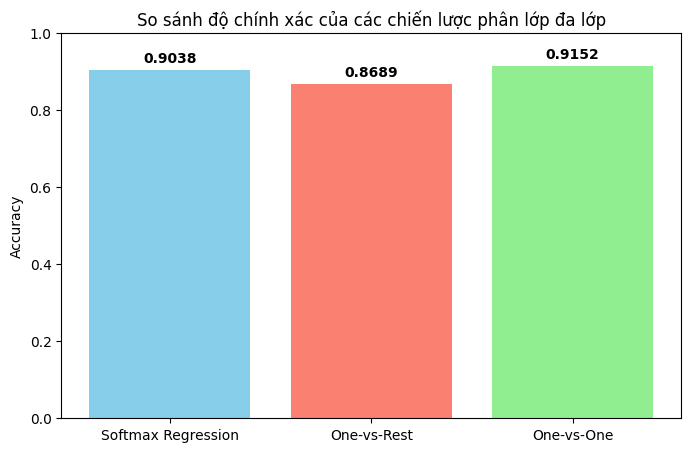

In [37]:
import numpy as np
import pandas as pd
from scipy.stats import mode

# 1. Thiết lập tham số chung
params = {
    'learning_rate': LEARNING_RATE,
    'max_iter': MAX_ITER,
    'random_state': SEED
}

# --- Chiến lược 1: Softmax Regression (Đa lớp trực tiếp) ---
print("Đang huấn luyện Softmax Regression...")
model_softmax = SoftmaxRegression(**params)
model_softmax.fit(X_train_scaled, y_train)
y_pred_softmax = model_softmax.predict(X_test_scaled)
acc_softmax = np.mean(y_pred_softmax == y_test)

# --- Chiến lược 2: One-vs-Rest (OvR) ---
print("Đang huấn luyện One-vs-Rest (OvR)...")
model_ovr = MulticlassLogisticRegression(method='ovr', **params)
model_ovr.fit(X_train_scaled, y_train)
y_pred_ovr = model_ovr.predict(X_test_scaled)
acc_ovr = np.mean(y_pred_ovr == y_test)

# --- Chiến lược 3: One-vs-One (OvO) ---
print("Đang huấn luyện One-vs-One (OvO)...")
model_ovo = MulticlassLogisticRegression(method='ovo', **params)
model_ovo.fit(X_train_scaled, y_train)
y_pred_ovo = model_ovo.predict(X_test_scaled)
acc_ovo = np.mean(y_pred_ovo == y_test)

# 2. Tổng hợp và hiển thị kết quả
results_data = {
    'Chiến lược': ['Softmax Regression', 'One-vs-Rest', 'One-vs-One'],
    'Độ chính xác (Accuracy)': [acc_softmax, acc_ovr, acc_ovo]
}

df_comparison = pd.DataFrame(results_data)

print("\n" + "="*40)
print("BẢNG SO SÁNH KẾT QUẢ")
print("="*40)
print(df_comparison.to_string(index=False))

# Tùy chọn: Vẽ biểu đồ cột để so sánh trực quan
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df_comparison['Chiến lược'], df_comparison['Độ chính xác (Accuracy)'], color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('So sánh độ chính xác của các chiến lược phân lớp đa lớp')
for i, v in enumerate(df_comparison['Độ chính xác (Accuracy)']):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

Trình bày đầy đủ đạo hàm Hessian, Jacobian của softmax.

Để triển khai **Softmax Regression** (còn gọi là Multinomial Logistic Regression) một cách chuyên sâu, việc hiểu các thành phần vi phân như Jacobian và Hessian là cực kỳ quan trọng để tối ưu hóa bằng các thuật toán bậc 1 (Gradient Descent) hoặc bậc 2 (Newton's Method).

Giả sử ta có vector đầu vào $z = [z_1, z_2, ..., z_K]^T$, hàm Softmax $\sigma(z)$ trả về một vector $a$ cùng chiều, với phần tử thứ $i$ là:
$$a_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

---

### 1. Ma trận Jacobian của Softmax
Ma trận Jacobian $J$ chứa tất cả các đạo hàm riêng bậc nhất của các đầu ra đối với các đầu vào. Vì mỗi $a_i$ phụ thuộc vào tất cả các $z_j$, ma trận này có kích thước $K \times K$.

Phần tử tại hàng $i$, cột $j$ của ma trận Jacobian là $\frac{\partial a_i}{\partial z_j}$:

*   **Trường hợp $i = j$ (Đạo hàm riêng với chính nó):**
    $$\frac{\partial a_i}{\partial z_i} = a_i(1 - a_i)$$
*   **Trường hợp $i \neq j$ (Đạo hàm riêng chéo):**
    $$\frac{\partial a_i}{\partial z_j} = -a_i a_j$$

**Dạng ma trận tổng quát:**
$$J = \text{diag}(a) - aa^T$$
Trong đó $\text{diag}(a)$ là ma trận đường chéo với các phần tử của vector $a$.

---

### 2. Đạo hàm của hàm mất mát (Gradient)
Trong bài toán phân lớp, Softmax luôn đi kèm với hàm mất mát **Cross-Entropy** ($L$). Giả sử $y$ là vector nhãn (one-hot vector). Gradient của $L$ đối với đầu vào $z$ có dạng cực kỳ đơn giản:

$$\nabla_z L = a - y$$

Đây chính là lý do vì sao cặp bài trùng Softmax và Cross-Entropy lại phổ biến đến vậy: lỗi (error) đơn giản là sự chênh lệch giữa xác suất dự đoán và nhãn thực tế.



---

### 3. Ma trận Hessian của Softmax
Ma trận Hessian $H$ là đạo hàm bậc hai của hàm mất mát $L$ đối với đầu vào $z$. Nó cho biết độ cong của bề mặt lỗi, giúp các thuật toán như Newton's Method hội tụ nhanh hơn.

Từ kết quả Gradient $\nabla_z L = a - y$, ta lấy đạo hàm một lần nữa theo $z$:
$$H = \frac{\partial^2 L}{\partial z^2} = \frac{\partial (a - y)}{\partial z}$$

Vì $y$ là hằng số đối với $z$, nên Hessian của hàm mất mát chính là **Jacobian của Softmax**:
$$H = \frac{\partial a}{\partial z} = \text{diag}(a) - aa^T$$

#### Đặc điểm của Hessian trong Softmax:
1.  **Kích thước:** $K \times K$.
2.  **Tính đối xứng:** $H_{ij} = H_{ji} = -a_i a_j$.
3.  **Bán xác định dương (Positive Semi-definite):** Điều này đảm bảo hàm mất mát Cross-Entropy là hàm lồi (convex), nghĩa là nếu ta tìm được cực tiểu thì đó chắc chắn là cực tiểu toàn cục.
4.  **Suy biến:** Ma trận này không nghịch đảo được vì tổng các hàng (hoặc cột) luôn bằng 0 (do $\sum a_i = 1$). Trong thực tế, người ta thường thêm một hạng tử điều hòa (regularization) để làm Hessian nghịch đảo được.

---

### Tóm tắt công thức triển khai

| Thành phần | Công thức | Ý nghĩa |
| :--- | :--- | :--- |
| **Output** | $a = \text{softmax}(z)$ | Dự đoán xác suất. |
| **Jacobian** | $J_{ij} = a_i(\delta_{ij} - a_j)$ | Tốc độ thay đổi của xác suất. |
| **Gradient** | $g = a - y$ | Hướng cập nhật trọng số (bậc 1). |
| **Hessian** | $H = \text{diag}(a) - aa^T$ | Độ cong của hàm lỗi (bậc 2). |

EVALUATION